In [1]:
import os
import json
import random
import inspect
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from scipy.special import expit

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score,
    log_loss,
    brier_score_loss,
)

from sklearn.preprocessing import KBinsDiscretizer
from sklearn.naive_bayes import CategoricalNB
from sklearn.neighbors import NearestNeighbors

# 1 Artifacts, configs

In [2]:
step1_dir = Path("./results_step1")
step2_dir = Path("./results_step2")
step4_dir = Path("./results_step4")
step4_dir.mkdir(parents=True, exist_ok=True)

step1_required_files = [
    "validation_pairs.parquet",
    "test_pairs.parquet",
    "validation_split_model_universe.parquet",
    "test_split_model_universe.parquet",
    "step1_config.json",
]

step2_required_files = [
    "final_train_pairs_used_by_bpr.parquet",
    "final_train_pairs_used_by_bpr_info.json",
    "user_embeddings_p_u.npy",
    "item_embeddings_q_i.npy",
    "item_bias.npy",
    "user_index_mapping.parquet",
    "item_index_mapping.parquet",
    "final_step2_config.json",
    "final_pairwise_evaluation.parquet",
]

def make_file_check(base_dir, filenames, source_name):
    rows = []

    for filename in filenames:
        path = base_dir / filename
        rows.append({
            "source": source_name,
            "filename": filename,
            "exists": path.exists(),
            "size_mb": round(path.stat().st_size / (1024 ** 2), 4) if path.exists() else np.nan,
        })

    return pd.DataFrame(rows)

artifact_check = pd.concat(
    [
        make_file_check(step1_dir, step1_required_files, "step1"),
        make_file_check(step2_dir, step2_required_files, "step2"),
    ],
    ignore_index=True,
)

display(artifact_check)

missing_files = artifact_check.loc[~artifact_check["exists"]]

if len(missing_files) > 0:
    display(missing_files)
    raise FileNotFoundError("Missing required artifacts for Step 4.")

with open(step1_dir / "step1_config.json", "r") as f:
    step1_config = json.load(f)

with open(step2_dir / "final_step2_config.json", "r") as f:
    step2_config = json.load(f)

random_seed = int(
    step2_config.get(
        "random_seed",
        step1_config.get("random_seed", step1_config.get("seed", 42)),
    )
)

random.seed(random_seed)
np.random.seed(random_seed)

config_summary = pd.DataFrame([
    {
        "config": "step1",
        "random_seed": step1_config.get("random_seed", step1_config.get("seed")),
        "pair_min_diff": step1_config.get("pair_min_diff"),
        "split_strategy": step1_config.get("split_strategy"),
    },
    {
        "config": "step2",
        "embedding_dim": step2_config.get("embedding_dim"),
        "learning_rate": step2_config.get("learning_rate"),
        "reg_lambda": step2_config.get("reg_lambda"),
        "selection_metric": step2_config.get("selection_metric"),
        "final_experiment_name": step2_config.get("final_experiment_name"),
        "test_used_for_selection": step2_config.get("test_used_for_selection"),
    },
])

display(config_summary)
print("Random seed used in Step 4:", random_seed)

,source,filename,exists,size_mb
0,step1,validation_pairs.parquet,True,1.9347
1,step1,test_pairs.parquet,True,2.0204
2,step1,validation_split_model_universe.parquet,True,1.0917
3,step1,test_split_model_universe.parquet,True,1.1787
4,step1,step1_config.json,True,0.0006
5,step2,final_train_pairs_used_by_bpr.parquet,True,22.8153
6,step2,final_train_pairs_used_by_bpr_info.json,True,0.0006
7,step2,user_embeddings_p_u.npy,True,1.1530
8,step2,item_embeddings_q_i.npy,True,0.7936
9,step2,item_bias.npy,True,0.0125


,config,random_seed,pair_min_diff,split_strategy,embedding_dim,learning_rate,reg_lambda,selection_metric,final_experiment_name,test_used_for_selection
0,step1,42.0,2.0,per_user_temporal_split_with_same_timestamp_gr...,NaN,NaN,NaN,NaN,NaN,NaN
1,step2,NaN,NaN,NaN,64.0,0.0003,0.0001,validation_macro_accuracy_best,pair_sampling_gap2_random_cap_dim64_lr3em04_re...,False


Random seed used in Step 4: 42


### Load Pairwise Data, Embeddings, Mappings

In [3]:
train_pairs = pd.read_parquet(step2_dir / "final_train_pairs_used_by_bpr.parquet")
val_pairs = pd.read_parquet(step1_dir / "validation_pairs.parquet")
test_pairs = pd.read_parquet(step1_dir / "test_pairs.parquet")

def standardize_pair_columns(pair_df):
    df = pair_df.copy()

    rename_map = {
        "preferred_item": "pos_item",
        "less_preferred_item": "neg_item",
        "rating_preferred": "rating_pos",
        "rating_less_preferred": "rating_neg",
        "timestamp_preferred": "timestamp_pos",
        "timestamp_less_preferred": "timestamp_neg",
    }

    active_rename_map = {
        old_name: new_name
        for old_name, new_name in rename_map.items()
        if old_name in df.columns
    }

    df = df.rename(columns=active_rename_map)

    required_columns = [
        "user_id",
        "pos_item",
        "neg_item",
        "rating_pos",
        "rating_neg",
        "rating_diff",
    ]

    missing_columns = [
        col for col in required_columns
        if col not in df.columns
    ]

    if missing_columns:
        raise ValueError(
            f"Missing required pairwise columns after standardization: {missing_columns}"
        )

    return df

train_pairs = standardize_pair_columns(train_pairs)
val_pairs = standardize_pair_columns(val_pairs)
test_pairs = standardize_pair_columns(test_pairs)

user_embeddings = np.load(step2_dir / "user_embeddings_p_u.npy").astype(np.float32)
item_embeddings = np.load(step2_dir / "item_embeddings_q_i.npy").astype(np.float32)
item_bias = np.load(step2_dir / "item_bias.npy").reshape(-1).astype(np.float32)

user_index_mapping = (
    pd.read_parquet(step2_dir / "user_index_mapping.parquet")
    .sort_values("user_idx")
    .reset_index(drop=True)
)

item_index_mapping = (
    pd.read_parquet(step2_dir / "item_index_mapping.parquet")
    .sort_values("item_idx")
    .reset_index(drop=True)
)

user_to_idx = dict(zip(user_index_mapping["user_id"], user_index_mapping["user_idx"]))
item_to_idx = dict(zip(item_index_mapping["movie_id"], item_index_mapping["item_idx"]))

n_users = len(user_index_mapping)
n_items = len(item_index_mapping)
embedding_dim = user_embeddings.shape[1]

assert np.isfinite(user_embeddings).all()
assert np.isfinite(item_embeddings).all()
assert np.isfinite(item_bias).all()
assert user_embeddings.shape[0] == n_users
assert item_embeddings.shape[0] == n_items
assert item_bias.shape[0] == n_items
assert user_embeddings.shape[1] == item_embeddings.shape[1]

print("Loaded Step 4 inputs.")
print("n_users:", n_users)
print("n_items:", n_items)
print("embedding_dim:", embedding_dim)

Loaded Step 4 inputs.
n_users: 4722
n_items: 3250
embedding_dim: 64


### Pair sanity and BPR indices

In [4]:
def pairwise_sanity_summary(pair_df, split_name):
    users = set(pair_df["user_id"].unique())
    items = set(pair_df["pos_item"].unique()) | set(pair_df["neg_item"].unique())

    semantic_duplicates = pair_df.duplicated(
        ["user_id", "pos_item", "neg_item"]
    ).sum()

    reverse_conflicts = len(
        set(zip(pair_df["user_id"], pair_df["pos_item"], pair_df["neg_item"]))
        &
        set(zip(pair_df["user_id"], pair_df["neg_item"], pair_df["pos_item"]))
    )

    return {
        "split": split_name,
        "rows": len(pair_df),
        "users": len(users),
        "items": len(items),
        "min_rating_diff": int(pair_df["rating_diff"].min()),
        "all_rating_diff_ge_2": bool(pair_df["rating_diff"].ge(2).all()),
        "same_pos_neg": int((pair_df["pos_item"] == pair_df["neg_item"]).sum()),
        "semantic_duplicates": int(semantic_duplicates),
        "reverse_conflicts": int(reverse_conflicts),
        "users_missing_from_bpr_mapping": len(users - set(user_to_idx.keys())),
        "items_missing_from_bpr_mapping": len(items - set(item_to_idx.keys())),
    }

pair_sanity = pd.DataFrame([
    pairwise_sanity_summary(train_pairs, "train_final_bpr_pairs"),
    pairwise_sanity_summary(val_pairs, "validation_pairs"),
    pairwise_sanity_summary(test_pairs, "test_pairs"),
])

display(pair_sanity)

assert pair_sanity["all_rating_diff_ge_2"].all()
assert pair_sanity["same_pos_neg"].sum() == 0
assert pair_sanity["semantic_duplicates"].sum() == 0
assert pair_sanity["reverse_conflicts"].sum() == 0
assert pair_sanity["users_missing_from_bpr_mapping"].sum() == 0
assert pair_sanity["items_missing_from_bpr_mapping"].sum() == 0

def add_pair_indices_if_needed(pair_df, split_name, user_to_idx, item_to_idx):
    df = pair_df.copy()

    if "user_idx" not in df.columns:
        df["user_idx"] = df["user_id"].map(user_to_idx)

    if "pos_item_idx" not in df.columns:
        df["pos_item_idx"] = df["pos_item"].map(item_to_idx)

    if "neg_item_idx" not in df.columns:
        df["neg_item_idx"] = df["neg_item"].map(item_to_idx)

    missing_summary = {
        "split": split_name,
        "rows": len(df),
        "missing_user_idx": int(df["user_idx"].isna().sum()),
        "missing_pos_item_idx": int(df["pos_item_idx"].isna().sum()),
        "missing_neg_item_idx": int(df["neg_item_idx"].isna().sum()),
    }

    if (
        missing_summary["missing_user_idx"] > 0
        or missing_summary["missing_pos_item_idx"] > 0
        or missing_summary["missing_neg_item_idx"] > 0
    ):
        raise ValueError(f"{split_name}: missing index mappings: {missing_summary}")

    df["user_idx"] = df["user_idx"].astype("int64")
    df["pos_item_idx"] = df["pos_item_idx"].astype("int64")
    df["neg_item_idx"] = df["neg_item_idx"].astype("int64")

    return df, missing_summary

train_pairs_idx, train_idx_summary = add_pair_indices_if_needed(
    train_pairs,
    "train",
    user_to_idx,
    item_to_idx,
)

val_pairs_idx, val_idx_summary = add_pair_indices_if_needed(
    val_pairs,
    "validation",
    user_to_idx,
    item_to_idx,
)

test_pairs_idx, test_idx_summary = add_pair_indices_if_needed(
    test_pairs,
    "test",
    user_to_idx,
    item_to_idx,
)

index_mapping_summary = pd.DataFrame([
    train_idx_summary,
    val_idx_summary,
    test_idx_summary,
])

display(index_mapping_summary)

assert index_mapping_summary[
    ["missing_user_idx", "missing_pos_item_idx", "missing_neg_item_idx"]
].sum().sum() == 0

print("Pairwise sanity and mapping checks passed.")

,split,rows,users,items,min_rating_diff,all_rating_diff_ge_2,same_pos_neg,semantic_duplicates,reverse_conflicts,users_missing_from_bpr_mapping,items_missing_from_bpr_mapping
0,train_final_bpr_pairs,5692244,4722,3250,2,True,0,0,0,0,0
1,validation_pairs,478098,4158,3193,2,True,0,0,0,0,0
2,test_pairs,507550,4164,3222,2,True,0,0,0,0,0


,split,rows,missing_user_idx,missing_pos_item_idx,missing_neg_item_idx
0,train,5692244,0,0,0
1,validation,478098,0,0,0
2,test,507550,0,0,0


Pairwise sanity and mapping checks passed.


### Directional classification view

In [5]:
def make_directional_arrays(
    pair_df_idx,
    mode,
    random_seed=42,
    sample_n=None,
):
    rng = np.random.default_rng(random_seed)

    if sample_n is not None and sample_n < len(pair_df_idx):
        row_idx = rng.choice(len(pair_df_idx), size=sample_n, replace=False)
        source_df = pair_df_idx.iloc[row_idx]
    else:
        source_df = pair_df_idx

    user_id = source_df["user_id"].to_numpy()
    user_idx = source_df["user_idx"].to_numpy(dtype=np.int64)

    pos_item = source_df["pos_item"].to_numpy()
    neg_item = source_df["neg_item"].to_numpy()

    pos_item_idx = source_df["pos_item_idx"].to_numpy(dtype=np.int64)
    neg_item_idx = source_df["neg_item_idx"].to_numpy(dtype=np.int64)

    if mode == "random_swap":
        swap_mask = rng.random(len(source_df)) < 0.5

        first_item = np.where(swap_mask, neg_item, pos_item)
        second_item = np.where(swap_mask, pos_item, neg_item)

        first_item_idx = np.where(swap_mask, neg_item_idx, pos_item_idx)
        second_item_idx = np.where(swap_mask, pos_item_idx, neg_item_idx)

        label = np.where(swap_mask, 0, 1).astype(np.int8)

        return {
            "mode": mode,
            "original_pair_count": len(source_df),
            "directional_row_count": len(source_df),
            "user_id": user_id,
            "user_idx": user_idx,
            "first_item": first_item,
            "second_item": second_item,
            "first_item_idx": first_item_idx.astype(np.int64),
            "second_item_idx": second_item_idx.astype(np.int64),
            "label": label,
        }

    if mode == "symmetric":
        return {
            "mode": mode,
            "original_pair_count": len(source_df),
            "directional_row_count": 2 * len(source_df),
            "user_id": np.concatenate([user_id, user_id]),
            "user_idx": np.concatenate([user_idx, user_idx]).astype(np.int64),
            "first_item": np.concatenate([pos_item, neg_item]),
            "second_item": np.concatenate([neg_item, pos_item]),
            "first_item_idx": np.concatenate([pos_item_idx, neg_item_idx]).astype(np.int64),
            "second_item_idx": np.concatenate([neg_item_idx, pos_item_idx]).astype(np.int64),
            "label": np.concatenate([
                np.ones(len(source_df), dtype=np.int8),
                np.zeros(len(source_df), dtype=np.int8),
            ]),
        }

    raise ValueError(f"Unknown directional mode: {mode}")

train_arrays = make_directional_arrays(
    train_pairs_idx,
    mode="random_swap",
    random_seed=random_seed,
)

val_arrays = make_directional_arrays(
    val_pairs_idx,
    mode="symmetric",
    random_seed=random_seed,
)

test_arrays = make_directional_arrays(
    test_pairs_idx,
    mode="symmetric",
    random_seed=random_seed,
)

def summarize_directional_arrays(arrays, split_name):
    return {
        "split": split_name,
        "mode": arrays["mode"],
        "original_pair_count": arrays["original_pair_count"],
        "directional_row_count": arrays["directional_row_count"],
        "positive_labels": int((arrays["label"] == 1).sum()),
        "negative_labels": int((arrays["label"] == 0).sum()),
        "positive_share": float((arrays["label"] == 1).mean()),
        "same_first_second_item": int(
            (arrays["first_item_idx"] == arrays["second_item_idx"]).sum()
        ),
    }

directional_summary = pd.DataFrame([
    summarize_directional_arrays(train_arrays, "train"),
    summarize_directional_arrays(val_arrays, "validation"),
    summarize_directional_arrays(test_arrays, "test"),
])

display(directional_summary)

assert directional_summary["same_first_second_item"].sum() == 0
print("Directional classification view is ready.")

,split,mode,original_pair_count,directional_row_count,positive_labels,negative_labels,positive_share,same_first_second_item
0,train,random_swap,5692244,5692244,2845051,2847193,0.499812,0
1,validation,symmetric,478098,956196,478098,478098,0.500000,0
2,test,symmetric,507550,1015100,507550,507550,0.500000,0


Directional classification view is ready.


### Feature groups and Feature builders

In [6]:
feature_group_plan = pd.DataFrame([
    {
        "feature_group": "item_diff",
        "feature_dim": embedding_dim + 1,
        "uses_user_vector": False,
        "uses_item_difference": True,
        "uses_user_item_interaction": False,
        "description": "q_first - q_second plus item bias difference",
    },
    {
        "feature_group": "interaction",
        "feature_dim": embedding_dim + 1,
        "uses_user_vector": True,
        "uses_item_difference": True,
        "uses_user_item_interaction": True,
        "description": "p_u * (q_first - q_second) plus item bias difference",
    },
    {
        "feature_group": "user_item_diff",
        "feature_dim": 2 * embedding_dim + 1,
        "uses_user_vector": True,
        "uses_item_difference": True,
        "uses_user_item_interaction": False,
        "description": "p_u concatenated with q_first - q_second plus item bias difference",
    },
])

display(feature_group_plan)

def slice_arrays(arrays, start, end):
    n_rows = len(arrays["label"])
    sliced = {}

    for key, value in arrays.items():
        if isinstance(value, np.ndarray) and len(value) == n_rows:
            sliced[key] = value[start:end]
        else:
            sliced[key] = value

    return sliced

def take_arrays(arrays, row_idx):
    n_rows = len(arrays["label"])
    taken = {}

    for key, value in arrays.items():
        if isinstance(value, np.ndarray) and len(value) == n_rows:
            taken[key] = value[row_idx]
        else:
            taken[key] = value

    taken["directional_row_count"] = len(row_idx)

    return taken

def sample_arrays(arrays, sample_n, random_seed=42):
    n_rows = len(arrays["label"])

    if sample_n is None or sample_n >= n_rows:
        return arrays

    rng = np.random.default_rng(random_seed)
    row_idx = rng.choice(n_rows, size=sample_n, replace=False)

    return take_arrays(arrays, row_idx)

def build_embedding_features(
    arrays,
    feature_group,
    user_embeddings,
    item_embeddings,
    item_bias,
):
    user_idx = arrays["user_idx"]
    first_item_idx = arrays["first_item_idx"]
    second_item_idx = arrays["second_item_idx"]

    user_vecs = user_embeddings[user_idx]
    first_item_vecs = item_embeddings[first_item_idx]
    second_item_vecs = item_embeddings[second_item_idx]

    item_diff = first_item_vecs - second_item_vecs
    bias_diff = (
        item_bias[first_item_idx] - item_bias[second_item_idx]
    ).reshape(-1, 1)

    if feature_group == "item_diff":
        features = np.hstack([item_diff, bias_diff])

    elif feature_group == "interaction":
        interaction = user_vecs * item_diff
        features = np.hstack([interaction, bias_diff])

    elif feature_group == "user_item_diff":
        features = np.hstack([user_vecs, item_diff, bias_diff])

    else:
        raise ValueError(f"Unknown feature group: {feature_group}")

    features = np.asarray(features, dtype=np.float32)
    labels = arrays["label"].astype(np.int8)

    return features, labels

def iter_feature_batches(
    arrays,
    feature_group,
    batch_size,
    user_embeddings,
    item_embeddings,
    item_bias,
):
    n_rows = len(arrays["label"])

    for start in range(0, n_rows, batch_size):
        end = min(start + batch_size, n_rows)
        batch_arrays = slice_arrays(arrays, start, end)

        feature_batch, label_batch = build_embedding_features(
            batch_arrays,
            feature_group,
            user_embeddings,
            item_embeddings,
            item_bias,
        )

        yield start, end, feature_batch, label_batch

preview_arrays = sample_arrays(
    train_arrays,
    sample_n=50_000,
    random_seed=random_seed,
)

feature_sanity_rows = []

for feature_group in feature_group_plan["feature_group"].tolist():
    preview_features, preview_labels = build_embedding_features(
        preview_arrays,
        feature_group,
        user_embeddings,
        item_embeddings,
        item_bias,
    )

    expected_dim = int(
        feature_group_plan.loc[
            feature_group_plan["feature_group"] == feature_group,
            "feature_dim",
        ].iloc[0]
    )

    feature_sanity_rows.append({
        "feature_group": feature_group,
        "rows": preview_features.shape[0],
        "feature_dim": preview_features.shape[1],
        "expected_feature_dim": expected_dim,
        "dtype": str(preview_features.dtype),
        "all_finite": bool(np.isfinite(preview_features).all()),
        "positive_share": float(preview_labels.mean()),
        "estimated_memory_mb": preview_features.nbytes / (1024 ** 2),
    })

    del preview_features
    del preview_labels

feature_sanity_summary = pd.DataFrame(feature_sanity_rows)
display(feature_sanity_summary.round(6))

assert feature_sanity_summary["all_finite"].all()
assert (
    feature_sanity_summary["feature_dim"]
    == feature_sanity_summary["expected_feature_dim"]
).all()

,feature_group,feature_dim,uses_user_vector,uses_item_difference,uses_user_item_interaction,description
0,item_diff,65,False,True,False,q_first - q_second plus item bias difference
1,interaction,65,True,True,True,p_u * (q_first - q_second) plus item bias diff...
2,user_item_diff,129,True,True,False,p_u concatenated with q_first - q_second plus ...


,feature_group,rows,feature_dim,expected_feature_dim,dtype,all_finite,positive_share,estimated_memory_mb
0,item_diff,50000,65,65,float32,True,0.4959,12.397766
1,interaction,50000,65,65,float32,True,0.4959,12.397766
2,user_item_diff,50000,129,129,float32,True,0.4959,24.604797


### Evaluation helpers and MF baseline

In [7]:
def safe_auc(y_true, y_prob):
    if len(np.unique(y_true)) < 2:
        return np.nan

    return roc_auc_score(y_true, y_prob)

def evaluate_probabilities(
    y_true,
    y_prob,
    split_name,
    model_name,
    model_family,
    feature_group,
    mode,
):
    y_prob = np.asarray(y_prob, dtype=np.float64)
    y_prob = np.clip(y_prob, 1e-12, 1 - 1e-12)
    y_pred = (y_prob >= 0.5).astype(np.int8)

    return {
        "model": model_name,
        "model_family": model_family,
        "feature_group": feature_group,
        "split": split_name,
        "mode": mode,
        "rows": int(len(y_true)),
        "positive_share": float(np.mean(y_true)),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "auc": float(safe_auc(y_true, y_prob)),
        "log_loss": float(log_loss(y_true, y_prob, labels=[0, 1])),
        "brier_score": float(brier_score_loss(y_true, y_prob)),
        "mean_predicted_probability": float(np.mean(y_prob)),
    }

def summarize_user_accuracy(
    arrays,
    y_prob,
    split_name,
    model_name,
    feature_group,
):
    y_true = arrays["label"]
    y_pred = (np.asarray(y_prob) >= 0.5).astype(np.int8)

    user_eval = pd.DataFrame({
        "user_id": arrays["user_id"],
        "correct": y_true == y_pred,
    })

    user_acc = (
        user_eval
        .groupby("user_id")["correct"]
        .agg(["count", "mean"])
        .reset_index()
        .rename(columns={
            "count": "directional_examples",
            "mean": "user_accuracy",
        })
    )

    summary = {
        "model": model_name,
        "feature_group": feature_group,
        "split": split_name,
        "users": int(len(user_acc)),
        "macro_user_accuracy": float(user_acc["user_accuracy"].mean()),
        "median_user_accuracy": float(user_acc["user_accuracy"].median()),
        "p10_user_accuracy": float(user_acc["user_accuracy"].quantile(0.10)),
        "p25_user_accuracy": float(user_acc["user_accuracy"].quantile(0.25)),
        "p75_user_accuracy": float(user_acc["user_accuracy"].quantile(0.75)),
        "p90_user_accuracy": float(user_acc["user_accuracy"].quantile(0.90)),
    }

    user_acc["model"] = model_name
    user_acc["feature_group"] = feature_group
    user_acc["split"] = split_name

    return summary, user_acc

def compute_directional_mf_score(
    arrays,
    user_embeddings,
    item_embeddings,
    item_bias,
):
    user_idx = arrays["user_idx"]
    first_item_idx = arrays["first_item_idx"]
    second_item_idx = arrays["second_item_idx"]

    user_vecs = user_embeddings[user_idx]
    first_item_vecs = item_embeddings[first_item_idx]
    second_item_vecs = item_embeddings[second_item_idx]

    item_diff = first_item_vecs - second_item_vecs
    bias_diff = item_bias[first_item_idx] - item_bias[second_item_idx]

    return np.sum(user_vecs * item_diff, axis=1) + bias_diff

val_mf_score = compute_directional_mf_score(
    val_arrays,
    user_embeddings,
    item_embeddings,
    item_bias,
)

test_mf_score = compute_directional_mf_score(
    test_arrays,
    user_embeddings,
    item_embeddings,
    item_bias,
)

val_mf_prob = expit(val_mf_score).astype(np.float32)
test_mf_prob = expit(test_mf_score).astype(np.float32)

mf_validation_eval = pd.DataFrame([
    evaluate_probabilities(
        y_true=val_arrays["label"],
        y_prob=val_mf_prob,
        split_name="validation",
        model_name="mf_score",
        model_family="matrix_factorization",
        feature_group="p_u_dot_q_diff_plus_bias_diff",
        mode="symmetric",
    )
])

mf_test_eval = pd.DataFrame([
    evaluate_probabilities(
        y_true=test_arrays["label"],
        y_prob=test_mf_prob,
        split_name="test",
        model_name="mf_score",
        model_family="matrix_factorization",
        feature_group="p_u_dot_q_diff_plus_bias_diff",
        mode="symmetric",
    )
])

display(mf_validation_eval.round(6))
display(mf_test_eval.round(6))

mf_val_user_summary, mf_val_user_acc = summarize_user_accuracy(
    val_arrays,
    val_mf_prob,
    split_name="validation",
    model_name="mf_score",
    feature_group="p_u_dot_q_diff_plus_bias_diff",
)

mf_test_user_summary, mf_test_user_acc = summarize_user_accuracy(
    test_arrays,
    test_mf_prob,
    split_name="test",
    model_name="mf_score",
    feature_group="p_u_dot_q_diff_plus_bias_diff",
)

display(pd.DataFrame([mf_val_user_summary, mf_test_user_summary]).round(6))

,model,model_family,feature_group,split,mode,rows,positive_share,accuracy,balanced_accuracy,auc,log_loss,brier_score,mean_predicted_probability
0,mf_score,matrix_factorization,p_u_dot_q_diff_plus_bias_diff,validation,symmetric,956196,0.5,0.809004,0.809004,0.896833,0.402563,0.130652,0.5


,model,model_family,feature_group,split,mode,rows,positive_share,accuracy,balanced_accuracy,auc,log_loss,brier_score,mean_predicted_probability
0,mf_score,matrix_factorization,p_u_dot_q_diff_plus_bias_diff,test,symmetric,1015100,0.5,0.818034,0.818034,0.903393,0.393546,0.125943,0.5


,model,feature_group,split,users,macro_user_accuracy,median_user_accuracy,p10_user_accuracy,p25_user_accuracy,p75_user_accuracy,p90_user_accuracy
0,mf_score,p_u_dot_q_diff_plus_bias_diff,validation,4158,0.760839,0.801585,0.5,0.660836,0.928571,1.0
1,mf_score,p_u_dot_q_diff_plus_bias_diff,test,4164,0.774218,0.823529,0.5,0.666667,0.938838,1.0


### Discretized Naive Bayes feature ablation

In [8]:
bayes_feature_groups = feature_group_plan["feature_group"].tolist()

bayes_n_bins = 8
bayes_bin_strategy = "quantile"
bayes_alpha = 1.0

bayes_discretizer_fit_sample_n = 300_000
bayes_batch_size = 250_000

def make_kbins_discretizer(
    n_bins,
    strategy,
    random_seed,
):
    signature = inspect.signature(KBinsDiscretizer)
    kwargs = {
        "n_bins": n_bins,
        "encode": "ordinal",
        "strategy": strategy,
    }

    if "dtype" in signature.parameters:
        kwargs["dtype"] = np.float32

    if "subsample" in signature.parameters:
        kwargs["subsample"] = None

    if "random_state" in signature.parameters:
        kwargs["random_state"] = random_seed

    if "quantile_method" in signature.parameters:
        kwargs["quantile_method"] = "averaged_inverted_cdf"

    return KBinsDiscretizer(**kwargs)

def discretize_features(discretizer, feature_batch, n_bins):
    discrete_batch = discretizer.transform(feature_batch)
    discrete_batch = np.asarray(discrete_batch, dtype=np.int16)
    discrete_batch = np.clip(discrete_batch, 0, n_bins - 1)

    return discrete_batch

def fit_categorical_nb(
    train_arrays,
    feature_group,
    user_embeddings,
    item_embeddings,
    item_bias,
    n_bins,
    bin_strategy,
    alpha,
    discretizer_fit_sample_n,
    batch_size,
    random_seed,
):
    fit_arrays = sample_arrays(
        train_arrays,
        sample_n=discretizer_fit_sample_n,
        random_seed=random_seed,
    )

    fit_features, fit_labels = build_embedding_features(
        fit_arrays,
        feature_group,
        user_embeddings,
        item_embeddings,
        item_bias,
    )

    discretizer = make_kbins_discretizer(
        n_bins=n_bins,
        strategy=bin_strategy,
        random_seed=random_seed,
    )

    discretizer.fit(fit_features)

    del fit_features
    del fit_labels

    nb_model = CategoricalNB(
        alpha=alpha,
        min_categories=n_bins,
    )

    first_batch = True
    classes = np.array([0, 1], dtype=np.int8)

    batch_rows = []
    train_positive_count = 0
    train_row_count = 0

    for start, end, feature_batch, label_batch in iter_feature_batches(
        train_arrays,
        feature_group,
        batch_size,
        user_embeddings,
        item_embeddings,
        item_bias,
    ):
        discrete_batch = discretize_features(
            discretizer,
            feature_batch,
            n_bins=n_bins,
        )

        if first_batch:
            nb_model.partial_fit(
                discrete_batch,
                label_batch,
                classes=classes,
            )
            first_batch = False
        else:
            nb_model.partial_fit(
                discrete_batch,
                label_batch,
            )

        train_positive_count += int(label_batch.sum())
        train_row_count += int(len(label_batch))

        batch_rows.append({
            "feature_group": feature_group,
            "start": int(start),
            "end": int(end),
            "rows": int(len(label_batch)),
            "positive_share": float(label_batch.mean()),
            "feature_dim": int(feature_batch.shape[1]),
        })

        del feature_batch
        del discrete_batch
        del label_batch

    train_summary = {
        "model": "categorical_nb",
        "feature_group": feature_group,
        "n_bins": int(n_bins),
        "bin_strategy": bin_strategy,
        "alpha": float(alpha),
        "train_rows": int(train_row_count),
        "train_positive_share": float(train_positive_count / train_row_count),
        "discretizer_fit_rows": int(
            min(discretizer_fit_sample_n, len(train_arrays["label"]))
            if discretizer_fit_sample_n is not None
            else len(train_arrays["label"])
        ),
        "batch_size": int(batch_size),
    }

    return {
        "model": nb_model,
        "discretizer": discretizer,
        "train_summary": train_summary,
        "batch_summary": pd.DataFrame(batch_rows),
    }

def predict_categorical_nb_prob(
    arrays,
    feature_group,
    model,
    discretizer,
    user_embeddings,
    item_embeddings,
    item_bias,
    n_bins,
    batch_size,
):
    n_rows = len(arrays["label"])
    y_prob = np.empty(n_rows, dtype=np.float32)

    for start, end, feature_batch, label_batch in iter_feature_batches(
        arrays,
        feature_group,
        batch_size,
        user_embeddings,
        item_embeddings,
        item_bias,
    ):
        discrete_batch = discretize_features(
            discretizer,
            feature_batch,
            n_bins=n_bins,
        )

        y_prob[start:end] = model.predict_proba(discrete_batch)[:, 1].astype(np.float32)

        del feature_batch
        del discrete_batch
        del label_batch

    return y_prob

bayes_models = {}
bayes_training_summaries = []
bayes_validation_eval_rows = []
bayes_validation_user_rows = []
bayes_validation_prob_by_feature = {}

for feature_group in bayes_feature_groups:
    print("=" * 100)
    print("Fitting discretized Naive Bayes feature group:", feature_group)
    print("=" * 100)

    fitted_bayes = fit_categorical_nb(
        train_arrays=train_arrays,
        feature_group=feature_group,
        user_embeddings=user_embeddings,
        item_embeddings=item_embeddings,
        item_bias=item_bias,
        n_bins=bayes_n_bins,
        bin_strategy=bayes_bin_strategy,
        alpha=bayes_alpha,
        discretizer_fit_sample_n=bayes_discretizer_fit_sample_n,
        batch_size=bayes_batch_size,
        random_seed=random_seed,
    )

    val_bayes_prob = predict_categorical_nb_prob(
        arrays=val_arrays,
        feature_group=feature_group,
        model=fitted_bayes["model"],
        discretizer=fitted_bayes["discretizer"],
        user_embeddings=user_embeddings,
        item_embeddings=item_embeddings,
        item_bias=item_bias,
        n_bins=bayes_n_bins,
        batch_size=bayes_batch_size,
    )

    val_eval = evaluate_probabilities(
        y_true=val_arrays["label"],
        y_prob=val_bayes_prob,
        split_name="validation",
        model_name="categorical_nb",
        model_family="bayesian",
        feature_group=feature_group,
        mode="symmetric",
    )

    val_user_summary, val_user_acc = summarize_user_accuracy(
        val_arrays,
        val_bayes_prob,
        split_name="validation",
        model_name="categorical_nb",
        feature_group=feature_group,
    )

    bayes_models[feature_group] = fitted_bayes
    bayes_training_summaries.append(fitted_bayes["train_summary"])
    bayes_validation_eval_rows.append(val_eval)
    bayes_validation_user_rows.append(val_user_summary)
    bayes_validation_prob_by_feature[feature_group] = val_bayes_prob

bayes_training_summary = pd.DataFrame(bayes_training_summaries)
bayes_validation_evaluation = (
    pd.DataFrame(bayes_validation_eval_rows)
    .sort_values(["accuracy", "auc"], ascending=False)
    .reset_index(drop=True)
)

bayes_validation_user_summary = (
    pd.DataFrame(bayes_validation_user_rows)
    .sort_values("macro_user_accuracy", ascending=False)
    .reset_index(drop=True)
)

display(bayes_training_summary)
display(bayes_validation_evaluation.round(6))
display(bayes_validation_user_summary.round(6))

Fitting discretized Naive Bayes feature group: item_diff
Fitting discretized Naive Bayes feature group: interaction
Fitting discretized Naive Bayes feature group: user_item_diff


,model,feature_group,n_bins,bin_strategy,alpha,train_rows,train_positive_share,discretizer_fit_rows,batch_size
0,categorical_nb,item_diff,8,quantile,1.0,5692244,0.499812,300000,250000
1,categorical_nb,interaction,8,quantile,1.0,5692244,0.499812,300000,250000
2,categorical_nb,user_item_diff,8,quantile,1.0,5692244,0.499812,300000,250000


,model,model_family,feature_group,split,mode,rows,positive_share,accuracy,balanced_accuracy,auc,log_loss,brier_score,mean_predicted_probability
0,categorical_nb,bayesian,interaction,validation,symmetric,956196,0.5,0.802220,0.802220,0.887670,1.701089,0.179917,0.499844
1,categorical_nb,bayesian,item_diff,validation,symmetric,956196,0.5,0.769697,0.769697,0.849684,2.689439,0.215807,0.499809
2,categorical_nb,bayesian,user_item_diff,validation,symmetric,956196,0.5,0.769670,0.769670,0.849680,2.689433,0.215807,0.499818


,model,feature_group,split,users,macro_user_accuracy,median_user_accuracy,p10_user_accuracy,p25_user_accuracy,p75_user_accuracy,p90_user_accuracy
0,categorical_nb,interaction,validation,4158,0.751255,0.798479,0.468691,0.646029,0.923077,1.0
1,categorical_nb,user_item_diff,validation,4158,0.708807,0.750000,0.384231,0.571429,0.900000,1.0
2,categorical_nb,item_diff,validation,4158,0.708777,0.750000,0.382619,0.571429,0.899846,1.0


### Evaluate best Bayesian model on test

In [9]:
best_bayes_feature_group = bayes_validation_evaluation.iloc[0]["feature_group"]
best_bayes_artifact = bayes_models[best_bayes_feature_group]

best_bayes_val_prob = bayes_validation_prob_by_feature[best_bayes_feature_group]

test_bayes_prob = predict_categorical_nb_prob(
    arrays=test_arrays,
    feature_group=best_bayes_feature_group,
    model=best_bayes_artifact["model"],
    discretizer=best_bayes_artifact["discretizer"],
    user_embeddings=user_embeddings,
    item_embeddings=item_embeddings,
    item_bias=item_bias,
    n_bins=bayes_n_bins,
    batch_size=bayes_batch_size,
)

bayes_test_eval = pd.DataFrame([
    evaluate_probabilities(
        y_true=test_arrays["label"],
        y_prob=test_bayes_prob,
        split_name="test",
        model_name="categorical_nb",
        model_family="bayesian",
        feature_group=best_bayes_feature_group,
        mode="symmetric",
    )
])

bayes_test_user_summary, bayes_test_user_acc = summarize_user_accuracy(
    test_arrays,
    test_bayes_prob,
    split_name="test",
    model_name="categorical_nb",
    feature_group=best_bayes_feature_group,
)

print("Best Bayesian feature group:", best_bayes_feature_group)
display(bayes_test_eval.round(6))
display(pd.DataFrame([bayes_test_user_summary]).round(6))

Best Bayesian feature group: interaction


,model,model_family,feature_group,split,mode,rows,positive_share,accuracy,balanced_accuracy,auc,log_loss,brier_score,mean_predicted_probability
0,categorical_nb,bayesian,interaction,test,symmetric,1015100,0.5,0.813489,0.813489,0.895352,1.72069,0.170871,0.49984


,model,feature_group,split,users,macro_user_accuracy,median_user_accuracy,p10_user_accuracy,p25_user_accuracy,p75_user_accuracy,p90_user_accuracy
0,categorical_nb,interaction,test,4164,0.769192,0.816412,0.5,0.666667,0.933333,1.0


### User-neighborhood kNN baseline

In [10]:
knn_metric = "cosine"
knn_k_candidates = [5, 10, 20, 50]
knn_max_k = max(knn_k_candidates)
knn_weight_epsilon = 1e-6
knn_batch_size = 20_000

def build_user_knn_table(
    user_embeddings,
    max_k,
    metric="cosine",
    weight_epsilon=1e-6,
):
    n_users = user_embeddings.shape[0]

    knn_index = NearestNeighbors(
        n_neighbors=max_k + 1,
        metric=metric,
        algorithm="auto",
    )

    knn_index.fit(user_embeddings)

    distances_raw, indices_raw = knn_index.kneighbors(user_embeddings)

    neighbor_indices = np.empty((n_users, max_k), dtype=np.int32)
    neighbor_distances = np.empty((n_users, max_k), dtype=np.float32)

    for user_idx in range(n_users):
        keep_mask = indices_raw[user_idx] != user_idx

        neighbor_indices[user_idx] = indices_raw[user_idx][keep_mask][:max_k]
        neighbor_distances[user_idx] = distances_raw[user_idx][keep_mask][:max_k]

    neighbor_weights = 1.0 / (neighbor_distances + weight_epsilon)
    neighbor_weights = neighbor_weights / neighbor_weights.sum(axis=1, keepdims=True)

    return {
        "neighbor_indices": neighbor_indices,
        "neighbor_distances": neighbor_distances,
        "neighbor_weights": neighbor_weights.astype(np.float32),
    }

user_knn_table = build_user_knn_table(
    user_embeddings=user_embeddings,
    max_k=knn_max_k,
    metric=knn_metric,
    weight_epsilon=knn_weight_epsilon,
)

def predict_user_knn_prob(
    arrays,
    user_embeddings,
    item_embeddings,
    item_bias,
    neighbor_indices,
    neighbor_weights,
    k,
    batch_size,
):
    n_rows = len(arrays["label"])
    y_prob = np.empty(n_rows, dtype=np.float32)

    for start in range(0, n_rows, batch_size):
        end = min(start + batch_size, n_rows)
        batch_arrays = slice_arrays(arrays, start, end)

        user_idx = batch_arrays["user_idx"]
        first_item_idx = batch_arrays["first_item_idx"]
        second_item_idx = batch_arrays["second_item_idx"]

        first_item_vecs = item_embeddings[first_item_idx]
        second_item_vecs = item_embeddings[second_item_idx]
        item_diff = first_item_vecs - second_item_vecs

        bias_diff = item_bias[first_item_idx] - item_bias[second_item_idx]

        batch_neighbor_indices = neighbor_indices[user_idx, :k]
        batch_neighbor_weights = neighbor_weights[user_idx, :k]
        batch_neighbor_weights = (
            batch_neighbor_weights
            / batch_neighbor_weights.sum(axis=1, keepdims=True)
        )

        neighbor_user_vecs = user_embeddings[batch_neighbor_indices]

        neighbor_scores = (
            np.einsum("bkd,bd->bk", neighbor_user_vecs, item_diff)
            + bias_diff.reshape(-1, 1)
        )

        neighbor_votes = (neighbor_scores > 0).astype(np.float32)

        y_prob[start:end] = np.sum(
            batch_neighbor_weights * neighbor_votes,
            axis=1,
        ).astype(np.float32)

        del batch_arrays
        del first_item_vecs
        del second_item_vecs
        del item_diff
        del neighbor_user_vecs
        del neighbor_scores
        del neighbor_votes

    return y_prob

knn_validation_eval_rows = []
knn_validation_prob_by_k = {}

for k in knn_k_candidates:
    print("Evaluating user-neighborhood kNN with k =", k)

    val_knn_prob = predict_user_knn_prob(
        arrays=val_arrays,
        user_embeddings=user_embeddings,
        item_embeddings=item_embeddings,
        item_bias=item_bias,
        neighbor_indices=user_knn_table["neighbor_indices"],
        neighbor_weights=user_knn_table["neighbor_weights"],
        k=k,
        batch_size=knn_batch_size,
    )

    val_eval = evaluate_probabilities(
        y_true=val_arrays["label"],
        y_prob=val_knn_prob,
        split_name="validation",
        model_name="user_knn",
        model_family="knn",
        feature_group=f"user_embedding_neighbors_k_{k}",
        mode="symmetric",
    )

    val_eval["k"] = int(k)

    knn_validation_eval_rows.append(val_eval)
    knn_validation_prob_by_k[k] = val_knn_prob

knn_validation_evaluation = (
    pd.DataFrame(knn_validation_eval_rows)
    .sort_values(["accuracy", "auc"], ascending=False)
    .reset_index(drop=True)
)

display(knn_validation_evaluation.round(6))

best_knn_k = int(knn_validation_evaluation.iloc[0]["k"])
best_knn_val_prob = knn_validation_prob_by_k[best_knn_k]

test_knn_prob = predict_user_knn_prob(
    arrays=test_arrays,
    user_embeddings=user_embeddings,
    item_embeddings=item_embeddings,
    item_bias=item_bias,
    neighbor_indices=user_knn_table["neighbor_indices"],
    neighbor_weights=user_knn_table["neighbor_weights"],
    k=best_knn_k,
    batch_size=knn_batch_size,
)

knn_test_eval = pd.DataFrame([
    evaluate_probabilities(
        y_true=test_arrays["label"],
        y_prob=test_knn_prob,
        split_name="test",
        model_name="user_knn",
        model_family="knn",
        feature_group=f"user_embedding_neighbors_k_{best_knn_k}",
        mode="symmetric",
    )
])

knn_val_user_summary, knn_val_user_acc = summarize_user_accuracy(
    val_arrays,
    best_knn_val_prob,
    split_name="validation",
    model_name="user_knn",
    feature_group=f"user_embedding_neighbors_k_{best_knn_k}",
)

knn_test_user_summary, knn_test_user_acc = summarize_user_accuracy(
    test_arrays,
    test_knn_prob,
    split_name="test",
    model_name="user_knn",
    feature_group=f"user_embedding_neighbors_k_{best_knn_k}",
)

print("Best kNN k:", best_knn_k)
display(knn_test_eval.round(6))
display(pd.DataFrame([knn_val_user_summary, knn_test_user_summary]).round(6))

Evaluating user-neighborhood kNN with k = 5
Evaluating user-neighborhood kNN with k = 10
Evaluating user-neighborhood kNN with k = 20
Evaluating user-neighborhood kNN with k = 50


,model,model_family,feature_group,split,mode,rows,positive_share,accuracy,balanced_accuracy,auc,log_loss,brier_score,mean_predicted_probability,k
0,user_knn,knn,user_embedding_neighbors_k_10,validation,symmetric,956196,0.5,0.803720,0.803720,0.849252,3.114714,0.168615,0.5,10
1,user_knn,knn,user_embedding_neighbors_k_20,validation,symmetric,956196,0.5,0.803394,0.803394,0.857481,2.680349,0.166728,0.5,20
2,user_knn,knn,user_embedding_neighbors_k_5,validation,symmetric,956196,0.5,0.803346,0.803346,0.838831,3.612230,0.172790,0.5,5
3,user_knn,knn,user_embedding_neighbors_k_50,validation,symmetric,956196,0.5,0.802735,0.802735,0.865000,2.367902,0.165226,0.5,50


Best kNN k: 10


,model,model_family,feature_group,split,mode,rows,positive_share,accuracy,balanced_accuracy,auc,log_loss,brier_score,mean_predicted_probability
0,user_knn,knn,user_embedding_neighbors_k_10,test,symmetric,1015100,0.5,0.814647,0.814647,0.857074,3.064826,0.161097,0.5


,model,feature_group,split,users,macro_user_accuracy,median_user_accuracy,p10_user_accuracy,p25_user_accuracy,p75_user_accuracy,p90_user_accuracy
0,user_knn,user_embedding_neighbors_k_10,validation,4158,0.756012,0.800000,0.47975,0.649180,0.928571,1.0
1,user_knn,user_embedding_neighbors_k_10,test,4164,0.772449,0.818714,0.50000,0.666667,0.937500,1.0


### Where kNN beats MF

In [11]:
train_pair_counts = (
    train_pairs_idx
    .groupby("user_id")
    .size()
    .rename("train_pairs")
    .reset_index()
)

test_user_comparison = (
    mf_test_user_acc[["user_id", "user_accuracy"]]
    .rename(columns={"user_accuracy": "mf_user_accuracy"})
    .merge(
        bayes_test_user_acc[["user_id", "user_accuracy"]]
        .rename(columns={"user_accuracy": "bayes_user_accuracy"}),
        on="user_id",
        how="inner",
    )
    .merge(
        knn_test_user_acc[["user_id", "user_accuracy"]]
        .rename(columns={"user_accuracy": "knn_user_accuracy"}),
        on="user_id",
        how="inner",
    )
    .merge(train_pair_counts, on="user_id", how="left")
)

test_user_comparison["bayes_minus_mf"] = (
    test_user_comparison["bayes_user_accuracy"]
    - test_user_comparison["mf_user_accuracy"]
)

test_user_comparison["knn_minus_mf"] = (
    test_user_comparison["knn_user_accuracy"]
    - test_user_comparison["mf_user_accuracy"]
)

test_user_comparison["knn_beats_mf"] = (
    test_user_comparison["knn_user_accuracy"]
    > test_user_comparison["mf_user_accuracy"]
)

test_user_comparison["bayes_beats_mf"] = (
    test_user_comparison["bayes_user_accuracy"]
    > test_user_comparison["mf_user_accuracy"]
)

test_user_comparison["train_pair_segment"] = pd.qcut(
    test_user_comparison["train_pairs"],
    q=4,
    duplicates="drop",
).astype(str)

user_segment_comparison = (
    test_user_comparison
    .groupby("train_pair_segment", observed=True)
    .agg(
        users=("user_id", "nunique"),
        mean_train_pairs=("train_pairs", "mean"),
        median_train_pairs=("train_pairs", "median"),
        mf_user_accuracy=("mf_user_accuracy", "mean"),
        bayes_user_accuracy=("bayes_user_accuracy", "mean"),
        knn_user_accuracy=("knn_user_accuracy", "mean"),
        bayes_minus_mf=("bayes_minus_mf", "mean"),
        knn_minus_mf=("knn_minus_mf", "mean"),
        share_users_where_bayes_beats_mf=("bayes_beats_mf", "mean"),
        share_users_where_knn_beats_mf=("knn_beats_mf", "mean"),
    )
    .reset_index()
)

display(user_segment_comparison.round(6))

overall_win_summary = pd.DataFrame([
    {
        "comparison": "bayes_vs_mf",
        "share_users_model_beats_mf": float(test_user_comparison["bayes_beats_mf"].mean()),
        "mean_user_accuracy_gap": float(test_user_comparison["bayes_minus_mf"].mean()),
    },
    {
        "comparison": "knn_vs_mf",
        "share_users_model_beats_mf": float(test_user_comparison["knn_beats_mf"].mean()),
        "mean_user_accuracy_gap": float(test_user_comparison["knn_minus_mf"].mean()),
    },
])

display(overall_win_summary.round(6))

,train_pair_segment,users,mean_train_pairs,median_train_pairs,mf_user_accuracy,bayes_user_accuracy,knn_user_accuracy,bayes_minus_mf,knn_minus_mf,share_users_where_bayes_beats_mf,share_users_where_knn_beats_mf
0,"(1716.0, 2000.0]",2081,1990.585296,2000.0,0.797791,0.792923,0.797378,-0.004868,-0.000413,0.361365,0.390678
1,"(21.999, 511.75]",1041,266.869356,254.0,0.746801,0.740936,0.742502,-0.005865,-0.004299,0.132565,0.138329
2,"(511.75, 1716.0]",1042,995.989443,948.5,0.754530,0.750027,0.752583,-0.004503,-0.001947,0.267754,0.279271


,comparison,share_users_model_beats_mf,mean_user_accuracy_gap
0,bayes_vs_mf,0.280740,-0.005026
1,knn_vs_mf,0.299712,-0.001769


### Comparison tables

In [12]:
best_bayes_validation_eval = (
    bayes_validation_evaluation
    .loc[bayes_validation_evaluation["feature_group"] == best_bayes_feature_group]
    .head(1)
    .copy()
)

best_knn_validation_eval = (
    knn_validation_evaluation
    .loc[knn_validation_evaluation["k"] == best_knn_k]
    .head(1)
    .copy()
)

validation_model_comparison = pd.concat(
    [
        mf_validation_eval,
        best_bayes_validation_eval,
        best_knn_validation_eval,
    ],
    ignore_index=True,
    sort=False,
)

test_model_comparison = pd.concat(
    [
        mf_test_eval,
        bayes_test_eval,
        knn_test_eval,
    ],
    ignore_index=True,
    sort=False,
)

validation_model_comparison = (
    validation_model_comparison
    .sort_values(["accuracy", "auc"], ascending=False)
    .reset_index(drop=True)
)

test_model_comparison = (
    test_model_comparison
    .sort_values(["accuracy", "auc"], ascending=False)
    .reset_index(drop=True)
)

display(validation_model_comparison.round(6))
display(test_model_comparison.round(6))

final_user_macro_comparison = pd.DataFrame([
    mf_val_user_summary,
    bayes_validation_user_summary.loc[
        bayes_validation_user_summary["feature_group"] == best_bayes_feature_group
    ].iloc[0].to_dict(),
    knn_val_user_summary,
    mf_test_user_summary,
    bayes_test_user_summary,
    knn_test_user_summary,
])

display(final_user_macro_comparison.round(6))

,model,model_family,feature_group,split,mode,rows,positive_share,accuracy,balanced_accuracy,auc,log_loss,brier_score,mean_predicted_probability,k
0,mf_score,matrix_factorization,p_u_dot_q_diff_plus_bias_diff,validation,symmetric,956196,0.5,0.809004,0.809004,0.896833,0.402563,0.130652,0.500000,NaN
1,user_knn,knn,user_embedding_neighbors_k_10,validation,symmetric,956196,0.5,0.803720,0.803720,0.849252,3.114714,0.168615,0.500000,10.0
2,categorical_nb,bayesian,interaction,validation,symmetric,956196,0.5,0.802220,0.802220,0.887670,1.701089,0.179917,0.499844,NaN


,model,model_family,feature_group,split,mode,rows,positive_share,accuracy,balanced_accuracy,auc,log_loss,brier_score,mean_predicted_probability
0,mf_score,matrix_factorization,p_u_dot_q_diff_plus_bias_diff,test,symmetric,1015100,0.5,0.818034,0.818034,0.903393,0.393546,0.125943,0.50000
1,user_knn,knn,user_embedding_neighbors_k_10,test,symmetric,1015100,0.5,0.814647,0.814647,0.857074,3.064826,0.161097,0.50000
2,categorical_nb,bayesian,interaction,test,symmetric,1015100,0.5,0.813489,0.813489,0.895352,1.720690,0.170871,0.49984


,model,feature_group,split,users,macro_user_accuracy,median_user_accuracy,p10_user_accuracy,p25_user_accuracy,p75_user_accuracy,p90_user_accuracy
0,mf_score,p_u_dot_q_diff_plus_bias_diff,validation,4158,0.760839,0.801585,0.500000,0.660836,0.928571,1.0
1,categorical_nb,interaction,validation,4158,0.751255,0.798479,0.468691,0.646029,0.923077,1.0
2,user_knn,user_embedding_neighbors_k_10,validation,4158,0.756012,0.800000,0.479750,0.649180,0.928571,1.0
3,mf_score,p_u_dot_q_diff_plus_bias_diff,test,4164,0.774218,0.823529,0.500000,0.666667,0.938838,1.0
4,categorical_nb,interaction,test,4164,0.769192,0.816412,0.500000,0.666667,0.933333,1.0
5,user_knn,user_embedding_neighbors_k_10,test,4164,0.772449,0.818714,0.500000,0.666667,0.937500,1.0


### Calibration data and plots

,probability_bin,rows,mean_predicted_probability,observed_positive_share,model,split
0,"(-0.001, 0.1]",192387,0.033504,0.038636,mf_score,validation
1,"(0.1, 0.2]",84011,0.147632,0.156991,mf_score,validation
2,"(0.2, 0.3]",70955,0.249317,0.254584,mf_score,validation
3,"(0.3, 0.4]",66248,0.349540,0.353067,mf_score,validation
4,"(0.4, 0.5]",64497,0.450069,0.453339,mf_score,validation


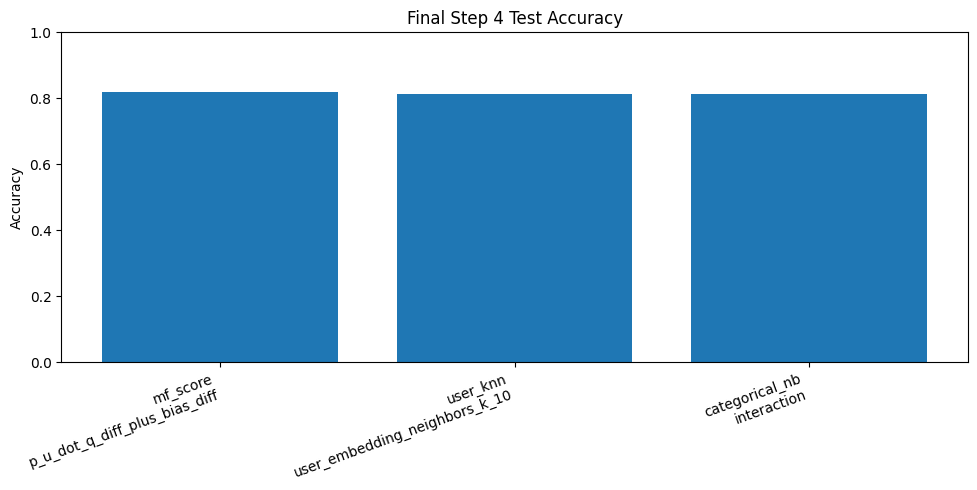

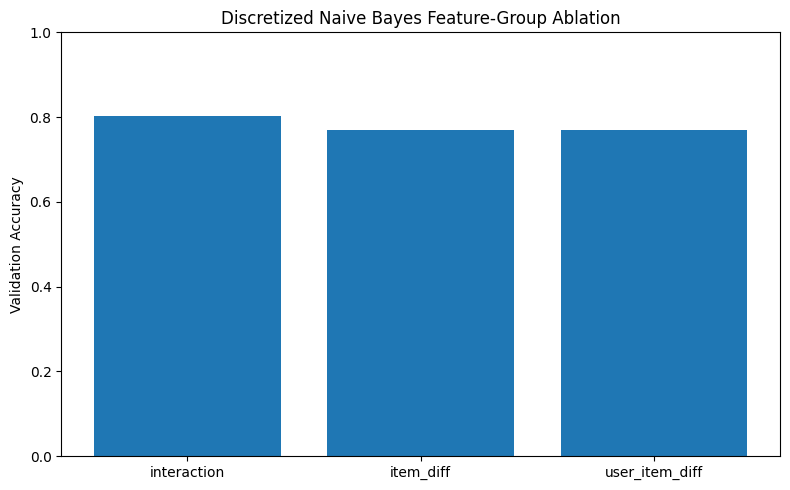

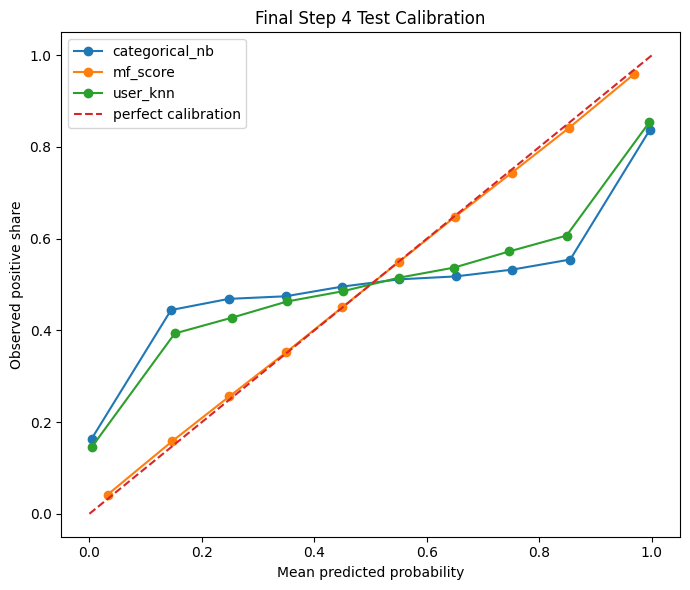

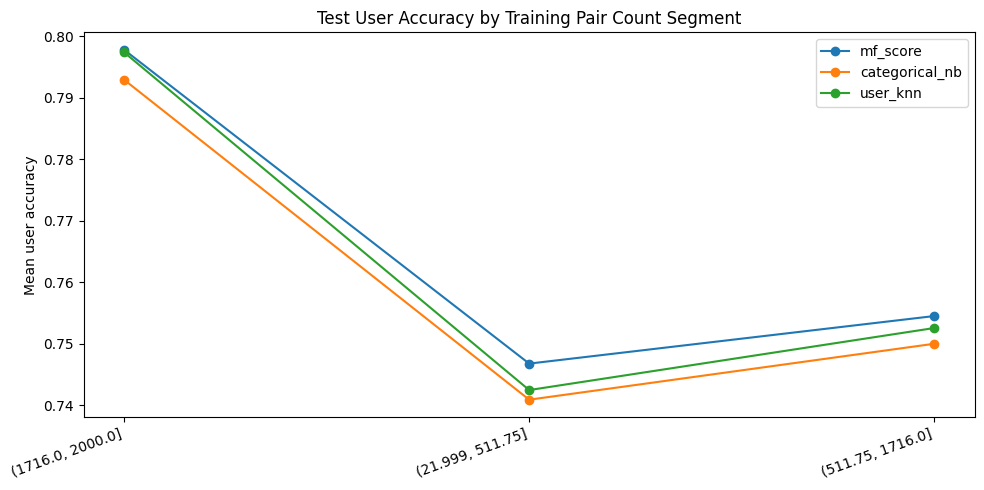

In [13]:
def make_calibration_table(
    y_true,
    y_prob,
    model_name,
    split_name,
    n_bins=10,
):
    temp = pd.DataFrame({
        "y_true": y_true.astype(np.int8),
        "y_prob": np.clip(y_prob.astype(np.float64), 0, 1),
    })

    temp["probability_bin"] = pd.cut(
        temp["y_prob"],
        bins=np.linspace(0, 1, n_bins + 1),
        include_lowest=True,
    )

    calibration = (
        temp
        .groupby("probability_bin", observed=True)
        .agg(
            rows=("y_true", "size"),
            mean_predicted_probability=("y_prob", "mean"),
            observed_positive_share=("y_true", "mean"),
        )
        .reset_index()
    )

    calibration["probability_bin"] = calibration["probability_bin"].astype(str)
    calibration["model"] = model_name
    calibration["split"] = split_name

    return calibration

calibration_comparison = pd.concat(
    [
        make_calibration_table(
            val_arrays["label"],
            val_mf_prob,
            model_name="mf_score",
            split_name="validation",
        ),
        make_calibration_table(
            val_arrays["label"],
            best_bayes_val_prob,
            model_name="categorical_nb",
            split_name="validation",
        ),
        make_calibration_table(
            val_arrays["label"],
            best_knn_val_prob,
            model_name="user_knn",
            split_name="validation",
        ),
        make_calibration_table(
            test_arrays["label"],
            test_mf_prob,
            model_name="mf_score",
            split_name="test",
        ),
        make_calibration_table(
            test_arrays["label"],
            test_bayes_prob,
            model_name="categorical_nb",
            split_name="test",
        ),
        make_calibration_table(
            test_arrays["label"],
            test_knn_prob,
            model_name="user_knn",
            split_name="test",
        ),
    ],
    ignore_index=True,
)

display(calibration_comparison.head())

plot_eval = test_model_comparison.copy()
plot_eval["model_label"] = (
    plot_eval["model"]
    + "\n"
    + plot_eval["feature_group"].astype(str)
)

plt.figure(figsize=(10, 5))
plt.bar(plot_eval["model_label"], plot_eval["accuracy"])
plt.ylabel("Accuracy")
plt.title("Final Step 4 Test Accuracy")
plt.xticks(rotation=20, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

plot_bayes = bayes_validation_evaluation.copy()

plt.figure(figsize=(8, 5))
plt.bar(plot_bayes["feature_group"], plot_bayes["accuracy"])
plt.ylabel("Validation Accuracy")
plt.title("Discretized Naive Bayes Feature-Group Ablation")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

plot_calibration = calibration_comparison[
    calibration_comparison["split"] == "test"
].copy()

plt.figure(figsize=(7, 6))

for model_name, model_df in plot_calibration.groupby("model"):
    plt.plot(
        model_df["mean_predicted_probability"],
        model_df["observed_positive_share"],
        marker="o",
        label=model_name,
    )

plt.plot([0, 1], [0, 1], linestyle="--", label="perfect calibration")
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed positive share")
plt.title("Final Step 4 Test Calibration")
plt.legend()
plt.tight_layout()
plt.show()

plot_segment = user_segment_comparison.copy()

plt.figure(figsize=(10, 5))
plt.plot(
    plot_segment["train_pair_segment"],
    plot_segment["mf_user_accuracy"],
    marker="o",
    label="mf_score",
)
plt.plot(
    plot_segment["train_pair_segment"],
    plot_segment["bayes_user_accuracy"],
    marker="o",
    label="categorical_nb",
)
plt.plot(
    plot_segment["train_pair_segment"],
    plot_segment["knn_user_accuracy"],
    marker="o",
    label="user_knn",
)
plt.ylabel("Mean user accuracy")
plt.title("Test User Accuracy by Training Pair Count Segment")
plt.xticks(rotation=20, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

### Save Results

In [14]:
final_test_predictions = pd.DataFrame({
    "user_id": test_arrays["user_id"],
    "first_item": test_arrays["first_item"],
    "second_item": test_arrays["second_item"],
    "y_true": test_arrays["label"],
    "mf_probability": test_mf_prob,
    "mf_prediction": (test_mf_prob >= 0.5).astype(np.int8),
    "bayes_probability": test_bayes_prob,
    "bayes_prediction": (test_bayes_prob >= 0.5).astype(np.int8),
    "knn_probability": test_knn_prob,
    "knn_prediction": (test_knn_prob >= 0.5).astype(np.int8),
})

final_step4_config = {
    "random_seed": int(random_seed),
    "train_direction_policy": "random_swap",
    "validation_test_direction_policy": "symmetric",
    "label_definition": "label=1 if first_item is preferred over second_item",
    "mf_baseline": "sigmoid(p_u dot (q_first - q_second) + bias_first - bias_second)",
    "bayesian_model": "CategoricalNB",
    "bayesian_feature_group_selected": best_bayes_feature_group,
    "bayesian_n_bins": int(bayes_n_bins),
    "bayesian_bin_strategy": bayes_bin_strategy,
    "bayesian_alpha": float(bayes_alpha),
    "bayesian_discretizer_fit_sample_n": int(bayes_discretizer_fit_sample_n),
    "bayesian_selection_metric": "validation_accuracy",
    "knn_model": "user_neighborhood_distance_weighted_vote",
    "knn_metric": knn_metric,
    "knn_k_candidates": [int(k) for k in knn_k_candidates],
    "knn_selected_k": int(best_knn_k),
    "knn_selection_metric": "validation_accuracy",
    "dbscan_used_in_step4": False,
    "saved_files": {
        "config": "final_step4_config.json",
        "validation_evaluation": "final_step4_validation_evaluation.parquet",
        "test_evaluation": "final_step4_test_evaluation.parquet",
        "bayesian_feature_ablation": "final_step4_bayesian_feature_ablation.parquet",
        "knn_validation_ablation": "final_step4_knn_validation_ablation.parquet",
        "user_macro_comparison": "final_step4_user_macro_comparison.parquet",
        "user_segment_comparison": "final_step4_user_segment_comparison.parquet",
        "calibration_comparison": "final_step4_calibration_comparison.parquet",
        "test_predictions": "final_step4_test_predictions.parquet",
        "bayesian_model": "final_step4_categorical_nb.joblib",
        "knn_neighbors": "final_step4_user_knn_neighbors.npz",
    },
}

validation_model_comparison.to_parquet(
    step4_dir / "final_step4_validation_evaluation.parquet",
    index=False,
)

test_model_comparison.to_parquet(
    step4_dir / "final_step4_test_evaluation.parquet",
    index=False,
)

bayes_validation_evaluation.to_parquet(
    step4_dir / "final_step4_bayesian_feature_ablation.parquet",
    index=False,
)

knn_validation_evaluation.to_parquet(
    step4_dir / "final_step4_knn_validation_ablation.parquet",
    index=False,
)

final_user_macro_comparison.to_parquet(
    step4_dir / "final_step4_user_macro_comparison.parquet",
    index=False,
)

user_segment_comparison.to_parquet(
    step4_dir / "final_step4_user_segment_comparison.parquet",
    index=False,
)

calibration_comparison.to_parquet(
    step4_dir / "final_step4_calibration_comparison.parquet",
    index=False,
)

final_test_predictions.to_parquet(
    step4_dir / "final_step4_test_predictions.parquet",
    index=False,
)

joblib.dump(
    {
        "model": best_bayes_artifact["model"],
        "discretizer": best_bayes_artifact["discretizer"],
        "feature_group": best_bayes_feature_group,
        "n_bins": bayes_n_bins,
        "bin_strategy": bayes_bin_strategy,
        "alpha": bayes_alpha,
    },
    step4_dir / "final_step4_categorical_nb.joblib",
)

np.savez_compressed(
    step4_dir / "final_step4_user_knn_neighbors.npz",
    neighbor_indices=user_knn_table["neighbor_indices"],
    neighbor_distances=user_knn_table["neighbor_distances"],
    neighbor_weights=user_knn_table["neighbor_weights"],
    selected_k=np.array([best_knn_k], dtype=np.int32),
)

with open(step4_dir / "final_step4_config.json", "w") as f:
    json.dump(final_step4_config, f, indent=2)

print("Saved final Step 4 outputs to:", step4_dir)
for filename in final_step4_config["saved_files"].values():
    print(step4_dir / filename)

Saved final Step 4 outputs to: results_step4
results_step4\final_step4_config.json
results_step4\final_step4_validation_evaluation.parquet
results_step4\final_step4_test_evaluation.parquet
results_step4\final_step4_bayesian_feature_ablation.parquet
results_step4\final_step4_knn_validation_ablation.parquet
results_step4\final_step4_user_macro_comparison.parquet
results_step4\final_step4_user_segment_comparison.parquet
results_step4\final_step4_calibration_comparison.parquet
results_step4\final_step4_test_predictions.parquet
results_step4\final_step4_categorical_nb.joblib
results_step4\final_step4_user_knn_neighbors.npz
